In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")
dual = ['#B9529F','gray']
triple = ['gray','Tab:red', 'Tab:blue']
triple_ff = ['gray', 'Tab:red','Tab:blue']
sixtus = ['gray', 'Tab:red', 'Tab:blue', 'Tab:red', 'gray', 'gray']
npy = ['gray','darkgreen']
agrp = ['gray','tab:brown']

In [ ]:
def preprocess_plot(df, cat_name , name,  palette, order, plotting = False):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        
        else:
            param_df = df
        
        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:
                should_plot = False
                # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                #                     equal_var = False)

                _, p = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna())
            
                print(column, combo, p)
               

           
        except ValueError:
            
            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())
                
                fig,ax = plt.subplots(figsize = (8,4))
            
                sns.swarmplot(x=cat_name, y =column, data= param_df, palette = palette, order = order, alpha = 0.7, size = 4)
                sns.boxplot(x=cat_name, y =column, data= param_df, palette = palette, order = order, boxprops=dict(alpha=0.5), width = 0.5)
                sns.despine()
                plt.title(column, pad = 20)
                plt.xticks(rotation = 90)
                plt.savefig(f'output_figures/{name}_{column}.png',dpi = 300, bbox_inches = 'tight')
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# ephys analysis

In [ ]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

include_gal = True

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)

cat = df.Behaviour_6hFD.unique()

if include_gal:
       gal = df[(df.Gal_positive == 'yes') & (df.Behaviour_6hFD == 'Agg+')] 
       no_gal = df[(df.Gal_positive == 'no') & (df.Behaviour_6hFD == 'Agg+')]
       ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[df.Behaviour_6hFD != 'Pre']])
       sample_num= int(no_gal.shape[0]/4)
       ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 62)]).reset_index(drop = True)

else:
       ephys = df[df.Gal_positive == 'Unknown']
  
# ephys.loc[ephys.Behaviour_6hFD.isin([ 'npy_100_paired']),'Behaviour_6hFD'] = 'npy_100'
     
# ephys.loc[ephys.Behaviour_6hFD.isin(['npy_10', 'npy_100']),'Behaviour_6hFD'] = 'npy'

ephys.to_csv('sampled_ephys_data.csv')

In [ ]:
behav = pd.read_csv('ephys_behav.csv')
ephys_behav = pd.merge(ephys, behav, on  = 'ID_mouse')
ephys_behav.columns = [col.replace('(', '_').replace(')', '_') for col in ephys_behav.columns]
ephys_behav.columns = [col.replace(' ', '_').replace('-', '_') for col in ephys_behav.columns]

In [ ]:
ephys_behav.columns

In [ ]:
percent_columns = ['Ih_at__120mV', 'CaT', 'Adaptive', 'Firing_freq__Hz__I0'] 
percentages_df = pd.DataFrame(index=ephys_behav['ID_mouse'].unique())

for column in percent_columns:
    percentages = ephys_behav.groupby('ID_mouse')[column].apply(lambda x: (x == 0).sum() / len(x) * 100)
    percentages_df[column + '_percent_nonzero'] = percentages

silent_percentages = ephys_behav.groupby('ID_mouse')['I_zero_reclassified'].apply(lambda x: (x == 'silent').sum() / len(x) * 100).reset_index(name='I_zero_reclassified' + '_percent_silent')
percentages_df = percentages_df.reset_index()
percentages_df.rename(columns={'index': 'ID_mouse'}, inplace=True)
percentages_df = pd.merge(percentages_df, silent_percentages, on='ID_mouse', how='outer')

percentages_df = pd.merge(percentages_df, behav, on = 'ID_mouse')




In [ ]:
for y in percentages_df.columns[1:-6]:
    if y != 'attack_since_contact':  # Skip the contact_latency column
        formula = 'attack_since_contact ~ ' + y
        try:
            model = smf.ols(formula, data=percentages_df).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_since_contact', y = y, data = percentages_df)
           
        except Exception as e:
            continue

0.03635851790913471 sPSC_Amplitude_pA_ 0.26039880870815557


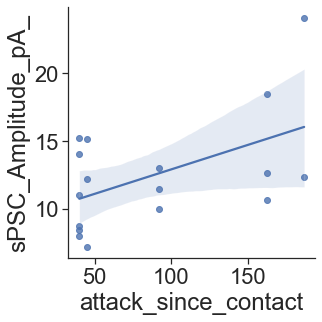

In [ ]:
#ephys correlation with behaviour metric
for y in ephys_behav.columns[8:-8]:
    if y != 'contact_latency':  # Skip the contact_latency column
        formula = 'attack_latency ~ ' + y
        try:
            model = smf.ols(formula, data=ephys_behav).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_latency', y = y, data = ephys_behav)
                plt.show()
           
        except Exception as e:
            continue
    

In [ ]:
ephys.Behaviour_6hFD.unique()

## all properties

Cm(pF) ('Pre', 'Agg+') 0.5478128358005985 0.7338867975518679 0.27390641790029924
Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.014807124800155693 0.0074035624000778465 0.9927024949062105
Firing_freq_(Hz)_I0 ('Pre', 'Agg-') 0.056508303792092644 0.972177780720702 0.028254151896046322
Firing_freq_(Hz)_I0 ('Pre', 'npy1r_antag') 0.252688674884768 0.8753852741732586 0.126344337442384
Firing_freq_(Hz)_I0 ('Pre', 'npy2r_antag') 0.9538747681412542 0.4769373840706271 0.5272497937168236
Firing_freq_(Hz)_I0 ('Pre', 'npy_10') 0.7410426214046371 0.6326346270209378 0.37052131070231853
Firing_freq_(Hz)_I0 ('Pre', 'ZD7288') 0.0017170461164481739 0.0008585230582240869 0.9991736798741285
Firing_freq_(Hz)_I0 ('Agg+', 'Agg-') 0.0003876130912269256 0.9998185472237288 0.0001938065456134628
Firing_freq_(Hz)_I0 ('Agg+', 'npy1r_antag') 0.015121232864767981 0.9928979918945997 0.007560616432383991
Firing_freq_(Hz)_I0 ('Agg+', 'npy2r_antag') 0.12311620240120107 0.941997240304866 0.06155810120060053
Firing_freq_(Hz)_I0 ('A

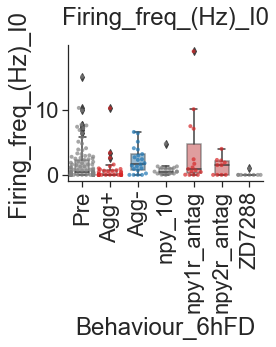

Instant_freq_(Hz) ('Pre', 'Agg+') 0.009287635057282254 0.004643817528641127 0.9954262781751356
Instant_freq_(Hz) ('Pre', 'Agg-') 0.14694272991012025 0.9274597828350386 0.07347136495506013
Instant_freq_(Hz) ('Pre', 'npy1r_antag') 0.3394466172966044 0.8323864517341661 0.1697233086483022
Instant_freq_(Hz) ('Pre', 'npy2r_antag') 0.9748322628751116 0.4874161314375558 0.5167763271965209
Instant_freq_(Hz) ('Pre', 'npy_10') 0.8050725511657608 0.6006976725212478 0.4025362755828804
Instant_freq_(Hz) ('Pre', 'ZD7288') 0.0021556187795441304 0.0010778093897720652 0.9989618869525647
Instant_freq_(Hz) ('Agg+', 'Agg-') 0.0010042335048808888 0.9995279065829772 0.0005021167524404444
Instant_freq_(Hz) ('Agg+', 'npy1r_antag') 0.01250590701292646 0.9941345938053727 0.00625295350646323
Instant_freq_(Hz) ('Agg+', 'npy2r_antag') 0.1464501473139031 0.9308467538253755 0.07322507365695155
Instant_freq_(Hz) ('Agg+', 'npy_10') 0.021917938100089865 0.9896701393173715 0.010958969050044932
Instant_freq_(Hz) ('Agg+', 

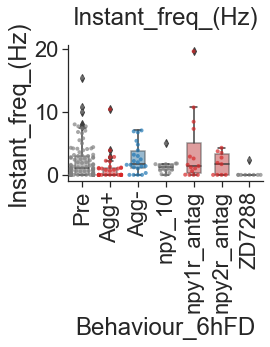

isi_(ms) ('Pre', 'Agg+') 0.7251347511724042 0.6414821313075381 0.3625673755862021
isi_(ms) ('Pre', 'Agg-') 0.0656361540509657 0.03281807702548285 0.9679143269830606
isi_(ms) ('Pre', 'npy1r_antag') 0.2975071455695215 0.14875357278476076 0.8541905541745136
isi_(ms) ('Pre', 'npy2r_antag') 0.25591347408218357 0.12795673704109178 0.8759555026317825
isi_(ms) ('Pre', 'npy_10') 0.18427028194902118 0.9097828491060865 0.09213514097451059
isi_(ms) ('Pre', 'ZD7288') 0.958904109589041 0.5342465753424659 0.4794520547945205
isi_(ms) ('Agg+', 'Agg-') 0.00918215781966879 0.004591078909834395 0.9958510574752473
isi_(ms) ('Agg+', 'npy1r_antag') 0.2752247359298454 0.1376123679649227 0.8723436128948773
isi_(ms) ('Agg+', 'npy2r_antag') 0.02960141927258719 0.014800709636293595 0.9877477248804839
isi_(ms) ('Agg+', 'npy_10') 0.49247835924189176 0.7666842188812268 0.24623917962094588
isi_(ms) ('Agg+', 'ZD7288') 0.6096148286886096 0.3048074143443048 0.762656139253769
isi_(ms) ('Agg-', 'npy1r_antag') 0.6566808075

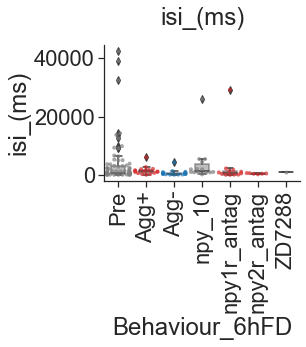

CaT ('Pre', 'Agg+') 0.44786541804310676 0.22393270902155338 0.77842491275807
CaT ('Pre', 'Agg-') 0.5457198326477843 0.7302689633387177 0.27285991632389217
CaT ('Pre', 'npy1r_antag') 0.416874334882375 0.2084371674411875 0.795022586905079
CaT ('Pre', 'npy2r_antag') 0.2348125970829542 0.1174062985414771 0.8856245899665456
CaT ('Pre', 'npy_10') 0.0324995015888171 0.01624975079440855 0.9842521623292244
CaT ('Pre', 'ZD7288') 0.6255791227700008 0.3127895613850004 0.6929479936856684
CaT ('Agg+', 'Agg-') 0.2071794724388344 0.8999981308434113 0.1035897362194172
CaT ('Agg+', 'npy1r_antag') 0.9890042530851655 0.49450212654258274 0.5164894445538895
CaT ('Agg+', 'npy2r_antag') 0.5332097757226921 0.26660488786134606 0.7456547919937762
CaT ('Agg+', 'npy_10') 0.1452209870584952 0.0726104935292476 0.9314882921021309
CaT ('Agg+', 'ZD7288') 0.9379573336186529 0.5464733800178562 0.4689786668093264
CaT ('Agg-', 'npy1r_antag') 0.16745288464179808 0.08372644232089904 0.9212747103262406
CaT ('Agg-', 'npy2r_ant

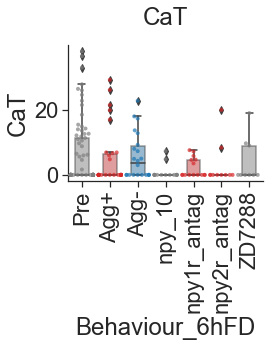

Ih_at_-120mV ('Pre', 'Agg+') 0.022582260847222646 0.011291130423611323 0.9889078012135821
Ih_at_-120mV ('Pre', 'Agg-') 0.4790416294467804 0.76310372845968 0.2395208147233902
Ih_at_-120mV ('Pre', 'npy1r_antag') 0.9360038311341023 0.4680019155670512 0.5362534244624569
Ih_at_-120mV ('Pre', 'npy2r_antag') 0.39241769940642823 0.19620884970321412 0.807496962067208
Ih_at_-120mV ('Pre', 'npy_10') 0.045981269203046994 0.022990634601523497 0.9775890999427158
Ih_at_-120mV ('Pre', 'ZD7288') 0.0004433783548300275 0.00022168917741501376 0.9997900939511978
Ih_at_-120mV ('Agg+', 'Agg-') 0.001072218802481044 0.9994965396316301 0.000536109401240522
Ih_at_-120mV ('Agg+', 'npy1r_antag') 0.13925173722266657 0.9334343996300307 0.06962586861133328
Ih_at_-120mV ('Agg+', 'npy2r_antag') 0.2466364642252239 0.8827113367200141 0.12331823211261195
Ih_at_-120mV ('Agg+', 'npy_10') 0.7859405901210211 0.39297029506051057 0.6160801579552541
Ih_at_-120mV ('Agg+', 'ZD7288') 0.002448378076647571 0.0012241890383237854 0.998

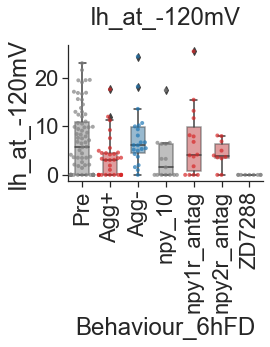

AP_ampl ('Pre', 'Agg+') 0.17166526974134844 0.08583263487067422 0.9162386714745587
AP_ampl ('Pre', 'Agg-') 0.5937244613471877 0.29686223067359385 0.7074162801673389
AP_ampl ('Pre', 'npy1r_antag') 0.0018155323915409233 0.0009077661957704616 0.9991398212273352
AP_ampl ('Pre', 'npy2r_antag') 0.1707474478495049 0.08537372392475245 0.9182235982030736
AP_ampl ('Pre', 'npy_10') 0.0047203524217950005 0.0023601762108975003 0.9977441509876979
AP_ampl ('Pre', 'ZD7288') 0.6327212360478085 0.31636061802390425 0.7045864114763782
AP_ampl ('Agg+', 'Agg-') 0.592731083459463 0.715454618755357 0.2963655417297315
AP_ampl ('Agg+', 'npy1r_antag') 0.06661785458821665 0.03330892729410832 0.9699922731546475
AP_ampl ('Agg+', 'npy2r_antag') 0.8536944923233335 0.42684724616166675 0.6018618519970463
AP_ampl ('Agg+', 'npy_10') 0.3282378266290379 0.16411891331451894 0.8459631743700208
AP_ampl ('Agg+', 'ZD7288') 0.9186079453512666 0.6204116615727016 0.4593039726756333
AP_ampl ('Agg-', 'npy1r_antag') 0.006323780925748

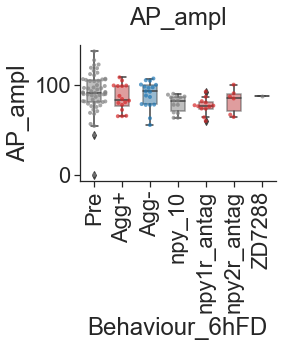

AP_halfwidth ('Pre', 'Agg+') 0.35692280485309436 0.8250522958898837 0.17846140242654718
AP_halfwidth ('Pre', 'Agg-') 0.08308572507672611 0.041542862538363055 0.9595649744505649
AP_halfwidth ('Pre', 'npy1r_antag') 0.9807412483433126 0.516046189378307 0.4903706241716563
AP_halfwidth ('Pre', 'npy2r_antag') 0.952515788663944 0.476257894331972 0.5332201083312614
AP_halfwidth ('Pre', 'npy_10') 0.5038756972693401 0.25193784863467006 0.7527263622897102
AP_halfwidth ('Pre', 'ZD7288') 0.8078449203901159 0.40392246019505795 0.6194394637761154
AP_halfwidth ('Agg+', 'Agg-') 0.028297488901750385 0.014148744450875193 0.9870488985837833
AP_halfwidth ('Agg+', 'npy1r_antag') 0.6257027677615872 0.3128513838807936 0.703412160914622
AP_halfwidth ('Agg+', 'npy2r_antag') 0.5802199276657589 0.29010996383287946 0.7346065662870886
AP_halfwidth ('Agg+', 'npy_10') 0.21945769429707374 0.10972884714853687 0.8978859935183136
AP_halfwidth ('Agg+', 'ZD7288') 0.7593198986790142 0.3796599493395071 0.6951925856556952
AP_

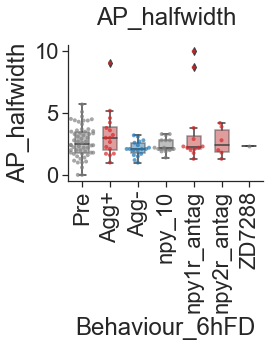

AP_time_to_peak ('Pre', 'Agg+') 0.7087191007219131 0.35435955036095657 0.6505918989036339
AP_time_to_peak ('Pre', 'Agg-') 0.8815081361133289 0.564141976312516 0.44075406805666445
AP_time_to_peak ('Pre', 'npy1r_antag') 0.018616372722913523 0.9910811740009984 0.009308186361456762
AP_time_to_peak ('Pre', 'npy2r_antag') 0.241146606314931 0.8840674425845283 0.1205733031574655
AP_time_to_peak ('Pre', 'npy_10') 0.15619990878153311 0.92399070915442 0.07809995439076656
AP_time_to_peak ('Pre', 'ZD7288') 0.5300813969081073 0.26504069845405365 0.7541728505167571
AP_time_to_peak ('Agg+', 'Agg-') 0.6534149862003124 0.6856521042638672 0.3267074931001562
AP_time_to_peak ('Agg+', 'npy1r_antag') 0.1429320808175019 0.93466508234091 0.07146604040875094
AP_time_to_peak ('Agg+', 'npy2r_antag') 0.35651136198434286 0.8403252758174751 0.17825568099217143
AP_time_to_peak ('Agg+', 'npy_10') 0.33841853575933345 0.8410823551571633 0.16920926787966672
AP_time_to_peak ('Agg+', 'ZD7288') 1.0 0.5 0.5810187646757508
AP

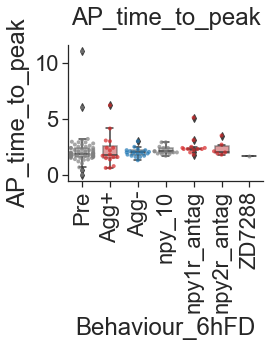

area(mV_ms) ('Pre', 'Agg+') 0.8414618490197195 0.42073092450985977 0.5844764751171945
area(mV_ms) ('Pre', 'Agg-') 0.03441863923068174 0.01720931961534087 0.9833123031819712
area(mV_ms) ('Pre', 'npy1r_antag') 0.33816577593712915 0.16908288796856458 0.8348791268000105
area(mV_ms) ('Pre', 'npy2r_antag') 0.39274781282741666 0.19637390641370833 0.810044348965194
area(mV_ms) ('Pre', 'npy_10') 0.11517747118588186 0.05758873559294093 0.9440594793586283
area(mV_ms) ('Pre', 'ZD7288') 0.5908385974339502 0.2954192987169751 0.7248654314878471
area(mV_ms) ('Agg+', 'Agg-') 0.36046646899140833 0.18023323449570416 0.8286859173410006
area(mV_ms) ('Agg+', 'npy1r_antag') 0.6258447297495924 0.3129223648747962 0.7033362428774506
area(mV_ms) ('Agg+', 'npy2r_antag') 0.5801129098052034 0.2900564549026017 0.7346646274265536
area(mV_ms) ('Agg+', 'npy_10') 0.5463471364069898 0.2731735682034949 0.7404864473118905
area(mV_ms) ('Agg+', 'ZD7288') 0.9186079453512666 0.6204116615727016 0.4593039726756333
area(mV_ms) ('

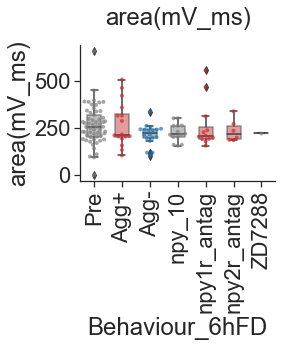

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.08941968161991616 0.9561033464063097 0.04470984080995808
rheobase_at_-60mV_(pA) ('Pre', 'Agg-') 0.1262400119204945 0.9382871299548479 0.06312000596024725
rheobase_at_-60mV_(pA) ('Pre', 'npy1r_antag') 0.19554128779794 0.904744356001066 0.09777064389897
rheobase_at_-60mV_(pA) ('Pre', 'npy2r_antag') 0.5189960284253445 0.7462730711005658 0.25949801421267227
rheobase_at_-60mV_(pA) ('Pre', 'npy_10') 0.2863099545612243 0.8600121799916264 0.14315497728061216
rheobase_at_-60mV_(pA) ('Pre', 'ZD7288') 0.038998267330366196 0.019499133665183098 0.9814445606836386
rheobase_at_-60mV_(pA) ('Agg+', 'Agg-') 0.7915786312985644 0.3957893156492822 0.6112146152857723
rheobase_at_-60mV_(pA) ('Agg+', 'npy1r_antag') 0.8198859098078219 0.40994295490391097 0.5993477789705054
rheobase_at_-60mV_(pA) ('Agg+', 'npy2r_antag') 0.6239970734406577 0.31199853672032885 0.6984340791169699
rheobase_at_-60mV_(pA) ('Agg+', 'npy_10') 0.25656714862234353 0.12828357431117177 0.87645823885

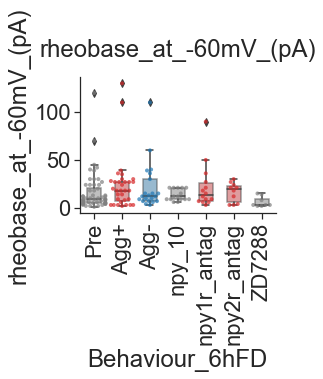

AHP_(mV) ('Pre', 'Agg+') 0.2305910954872582 0.8873172498068527 0.1152955477436291
AHP_(mV) ('Pre', 'Agg-') 0.5923087973031331 0.7081860214172212 0.29615439865156656
AHP_(mV) ('Pre', 'npy1r_antag') 0.09586259921170794 0.9536516353385255 0.04793129960585397
AHP_(mV) ('Pre', 'npy2r_antag') 0.39792444272912486 0.8076163919621765 0.19896222136456243
AHP_(mV) ('Pre', 'npy_10') 0.9648619645784112 0.5234194666731513 0.4824309822892056
AHP_(mV) ('Pre', 'ZD7288') 1.0 0.5 0.5242371504781634
AHP_(mV) ('Agg+', 'Agg-') 0.41739384189771966 0.20869692094885983 0.8010728310618571
AHP_(mV) ('Agg+', 'npy1r_antag') 0.3411227629459369 0.8409538201106179 0.17056138147296845
AHP_(mV) ('Agg+', 'npy2r_antag') 1.0 0.5147101829769678 0.5147101829769678
AHP_(mV) ('Agg+', 'npy_10') 0.2886928136675756 0.1443464068337878 0.8648998018778462
AHP_(mV) ('Agg+', 'ZD7288') 0.4744164892485241 0.23720824462426204 0.8211316722334041
AHP_(mV) ('Agg-', 'npy1r_antag') 0.13279539648494482 0.9388887752860858 0.06639769824247241
A

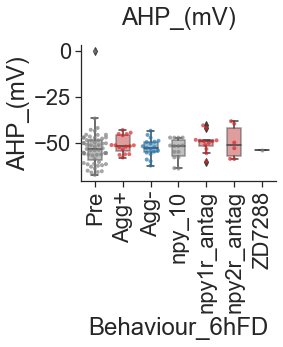

Vm ('Pre', 'Agg+') 0.45919463124778914 0.7719643766230047 0.22959731562389457
Vm ('Pre', 'Agg-') 0.4065705131864982 0.7986092909782585 0.2032852565932491
Vm ('Pre', 'npy1r_antag') 0.054906646563235836 0.9730722388065357 0.027453323281617918
Vm ('Pre', 'npy2r_antag') 0.9205633371833036 0.4602816685916518 0.5438831104940791
Vm ('Pre', 'npy_10') 0.39718987214012036 0.8037336523375658 0.19859493607006018
Vm ('Pre', 'ZD7288') 0.050421479951831376 0.9754364317315496 0.025210739975915688
Vm ('Agg+', 'Agg-') 0.9665448815248465 0.48327244076242326 0.5234119947081747
Vm ('Agg+', 'npy1r_antag') 0.3565400690202095 0.8273312455191164 0.17827003451010476
Vm ('Agg+', 'npy2r_antag') 0.8336291063696482 0.4168145531848241 0.5940811706684028
Vm ('Agg+', 'npy_10') 0.9222232024450479 0.5474930487590403 0.4611116012225239
Vm ('Agg+', 'ZD7288') 0.21534892291461338 0.8977519936943024 0.10767446145730669
Vm ('Agg-', 'npy1r_antag') 0.15927452165285128 0.9248468101477252 0.07963726082642564
Vm ('Agg-', 'npy2r_an

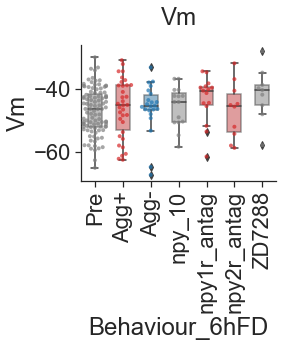

Input_Resistance ('Pre', 'Agg+') 0.005815031420767327 0.9971511276571083 0.0029075157103836636
Input_Resistance ('Pre', 'Agg-') 0.9966422937119996 0.5050364405077855 0.4983211468559998
Input_Resistance ('Pre', 'npy1r_antag') 0.12800381529415228 0.9373116210766081 0.06400190764707614
Input_Resistance ('Pre', 'npy2r_antag') 0.28404708941984524 0.8609461090925736 0.14202354470992262
Input_Resistance ('Pre', 'npy_10') 0.0006156751588977903 0.9997039231560353 0.00030783757944889516
Input_Resistance ('Pre', 'ZD7288') 0.00044327207068689816 0.9997898447109396 0.00022163603534344908
Input_Resistance ('Agg+', 'Agg-') 0.06326749519173107 0.031633747595865534 0.9695975681915016
Input_Resistance ('Agg+', 'npy1r_antag') 0.5007807675612952 0.2503903837806476 0.7568119516728391
Input_Resistance ('Agg+', 'npy2r_antag') 0.5848255600049787 0.2924127800024893 0.7176525775889959
Input_Resistance ('Agg+', 'npy_10') 0.2585294183552095 0.8754831269827216 0.12926470917760474
Input_Resistance ('Agg+', 'ZD7288'

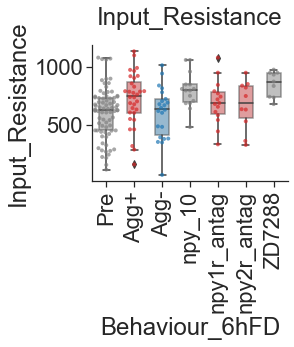

sPSC_frequency ('Pre', 'Agg+') 0.5476510222580521 0.27382551112902603 0.7302452298535232
sPSC_frequency ('Pre', 'Agg-') 0.10819724752370144 0.05409862376185072 0.947761838204342
sPSC_frequency ('Pre', 'npy1r_antag') 0.011956030052197754 0.9943885747001207 0.005978015026098877
sPSC_frequency ('Pre', 'npy2r_antag') 0.05590947589459569 0.9738398286794087 0.027954737947297845
sPSC_frequency ('Pre', 'npy_10') 0.11794717340399344 0.9445436517263355 0.05897358670199672
sPSC_frequency ('Pre', 'ZD7288') 8.427156354363181e-05 4.2135781771815905e-05 0.9999658601788028
sPSC_frequency ('Agg+', 'Agg-') 0.3985498130930386 0.1992749065465193 0.8052726088045472
sPSC_frequency ('Agg+', 'npy1r_antag') 0.005196291673863362 0.9975670345558795 0.002598145836931681
sPSC_frequency ('Agg+', 'npy2r_antag') 0.034347983647153836 0.9839541033416586 0.017173991823576918
sPSC_frequency ('Agg+', 'npy_10') 0.0758831852263595 0.9643991480199227 0.03794159261317975
sPSC_frequency ('Agg+', 'ZD7288') 0.0012361034761739548

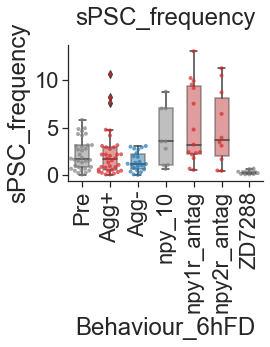

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.8251795081413411 0.41258975407067056 0.5921813148857779
sPSC_Amplitude(pA) ('Pre', 'Agg-') 0.050095923041863805 0.025047961520931902 0.9759412642639025
sPSC_Amplitude(pA) ('Pre', 'npy1r_antag') 0.664463697288834 0.332231848644417 0.6758059831655283
sPSC_Amplitude(pA) ('Pre', 'npy2r_antag') 0.2272372265227075 0.8918183701559144 0.11361861326135375
sPSC_Amplitude(pA) ('Pre', 'npy_10') 1.0 0.5 0.5122284948425014
sPSC_Amplitude(pA) ('Pre', 'ZD7288') 0.002609113660260992 0.001304556830130496 0.9988299730756283
sPSC_Amplitude(pA) ('Agg+', 'Agg-') 0.07793518102793069 0.038967590513965346 0.9623958908911516
sPSC_Amplitude(pA) ('Agg+', 'npy1r_antag') 0.7669318445476336 0.3834659222738168 0.6245911327624554
sPSC_Amplitude(pA) ('Agg+', 'npy2r_antag') 0.23497911855954945 0.8878040022631759 0.11748955927977472
sPSC_Amplitude(pA) ('Agg+', 'npy_10') 0.8159050834956846 0.6033072248253247 0.4079525417478423
sPSC_Amplitude(pA) ('Agg+', 'ZD7288') 0.003519475451705829 

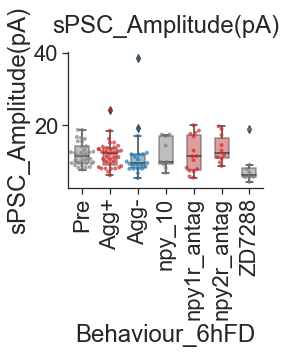

sPSCs_Rise time ('Pre', 'Agg+') 0.6786244023089005 0.6652044884542629 0.33931220115445027
sPSCs_Rise time ('Pre', 'Agg-') 0.3970241676687203 0.19851208383436014 0.8062699201116964
sPSCs_Rise time ('Pre', 'npy1r_antag') 0.9820976399517795 0.4910488199758897 0.517897854308699
sPSCs_Rise time ('Pre', 'npy2r_antag') 0.9768442965316141 0.48842214826580704 0.5231459541923411
sPSCs_Rise time ('Pre', 'npy_10') 0.6762317557648871 0.6731199873706264 0.33811587788244357
sPSCs_Rise time ('Pre', 'ZD7288') 0.5400376799085684 0.7408208026759457 0.2700188399542842
sPSCs_Rise time ('Agg+', 'Agg-') 0.28800329378154943 0.14400164689077471 0.8597028145353853
sPSCs_Rise time ('Agg+', 'npy1r_antag') 0.8897967889943941 0.44489839449719704 0.563511598611431
sPSCs_Rise time ('Agg+', 'npy2r_antag') 0.8906862639698255 0.44534313198491277 0.5654977323720025
sPSCs_Rise time ('Agg+', 'npy_10') 0.9299441139121688 0.5466572209112233 0.4649720569560844
sPSCs_Rise time ('Agg+', 'ZD7288') 0.7183881796222331 0.6524603677

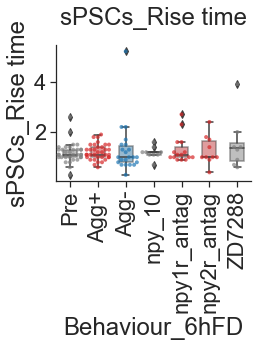

sPSCs (decay) ('Pre', 'Agg+') 0.34324972522993846 0.8315521362848035 0.17162486261496923
sPSCs (decay) ('Pre', 'Agg-') 0.5852881642217079 0.7135773222548022 0.29264408211085396
sPSCs (decay) ('Pre', 'npy1r_antag') 0.18937115235964863 0.9091054715349195 0.09468557617982432
sPSCs (decay) ('Pre', 'npy2r_antag') 0.29435613580791864 0.8595169674272871 0.14717806790395932
sPSCs (decay) ('Pre', 'npy_10') 0.08583563248185513 0.9598808560774906 0.04291781624092757
sPSCs (decay) ('Pre', 'ZD7288') 0.33514868886616145 0.16757434443308072 0.8407663319762118
sPSCs (decay) ('Agg+', 'Agg-') 0.8456730469762357 0.42283652348811784 0.5837778183353824
sPSCs (decay) ('Agg+', 'npy1r_antag') 0.5322649886463691 0.7407707739294447 0.26613249432318453
sPSCs (decay) ('Agg+', 'npy2r_antag') 0.7124446057230172 0.6539020219321974 0.3562223028615086
sPSCs (decay) ('Agg+', 'npy_10') 0.38264924176826665 0.8165050918568335 0.19132462088413332
sPSCs (decay) ('Agg+', 'ZD7288') 0.2678725495662825 0.13393627478314124 0.872

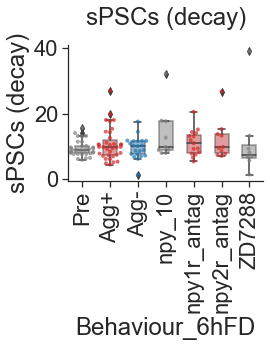

In [ ]:
filter_cat = ['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100', 'npy1r_antag', 'npy2r_antag', 'npykd']


preprocess_plot(ephys[ephys.Behaviour_6hFD.isin(filter_cat)],'Behaviour_6hFD', 'pan', 
                palette=['Gray', 'Tab:red', 'Tab:Blue', 'Gray', 'Gray', 'Tab:red', 'Tab:red', 'Tab:red'], order = filter_cat,
                  plotting= True)


## Individual plots - panMPOA

In [11]:
# subset df for those groups needed for firing freq. plot
ephys2 = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg-') |(ephys['Behaviour_6hFD'] == 'Agg+')]

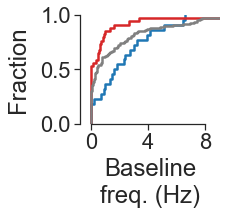

In [12]:
# Firing frequency

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = triple_ff, linewidth=2.5, legend=False,
                   stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [13]:
# subset df for those groups needed for firing freq. plot - ALL GROUPS
ephys2_all = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg-') |(ephys['Behaviour_6hFD'] == 'Agg+') |
                      (ephys['Behaviour_6hFD'] == 'npy_antag') | (ephys['Behaviour_6hFD'] == 'npy_KD_dummy') |(ephys['Behaviour_6hFD'] == 'ZD7288')]

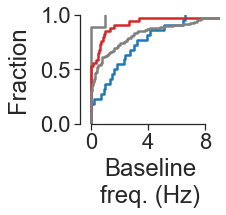

In [14]:
# Firing frequency - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2_all, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = sixtus, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

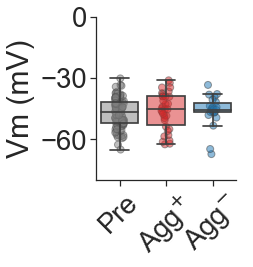

In [15]:
# Membrane voltage / RMP

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

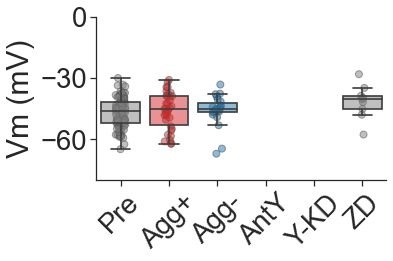

In [16]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_KD_dummy', 'ZD7288'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = sixtus)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order = ['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_KD_dummy', 'ZD7288'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = sixtus, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'AntY', 'Y-KD', 'ZD'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm_all.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

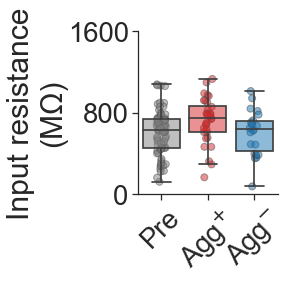

In [17]:
# Input resistance

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Input resistance\n(MΩ)', labelpad=0)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

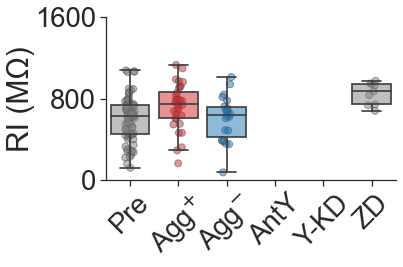

In [18]:
# Input resistance - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_KD_dummy', 'ZD7288'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = sixtus)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_KD_dummy', 'ZD7288'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = sixtus, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$', 'AntY', 'Y-KD', 'ZD'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri_all.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

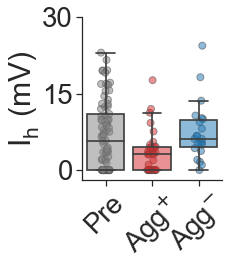

In [19]:
# Ih
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

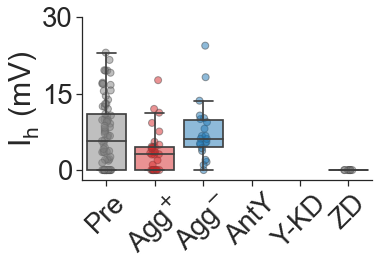

In [20]:
# Ih - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_KD_dummy', 'ZD7288'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = sixtus)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_KD_dummy', 'ZD7288'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = sixtus, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$', 'AntY', 'Y-KD', 'ZD'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_all.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

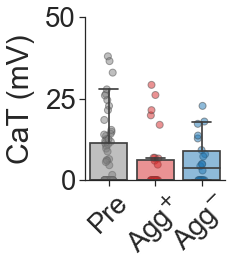

In [21]:
# CaT
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='CaT', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='CaT', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('CaT (mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(0, 50)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/cat.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

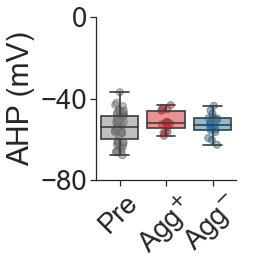

In [22]:
# AHP

ephys_filtered = ephys[ephys['AHP_(mV)'] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AHP_(mV)', data = ephys_filtered, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AHP_(mV)', data = ephys_filtered, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('AHP (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(-80, 0)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ahp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

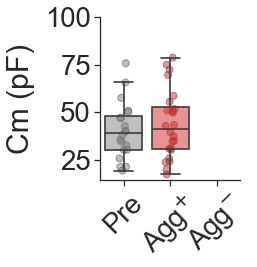

In [23]:
# Cm
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Cm(pF)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Cm(pF)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(top=100)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

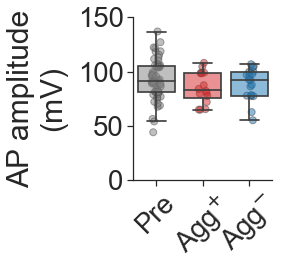

In [24]:
# AP_ampl
ephys_filt = ephys[ephys['AP_ampl'] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AP_ampl', data = ephys_filt, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AP_ampl', data = ephys_filt, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP amplitude\n(mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(0,150)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_ampl.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

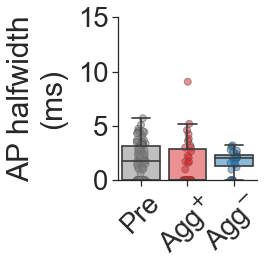

In [25]:
# AP_halfwidth
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AP_halfwidth', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AP_halfwidth', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP halfwidth\n(ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,15)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_halfwidth.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

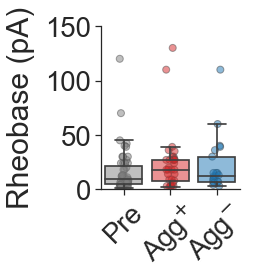

In [26]:
# rheobase_at_-60mV_(pA)
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='rheobase_at_-60mV_(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='rheobase_at_-60mV_(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('Rheobase (pA)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,150)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/rheo.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

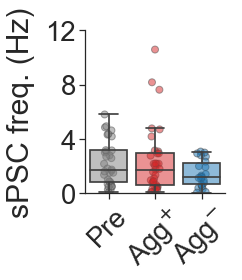

In [27]:
# sPSC_frequency
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSC_frequency', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSC_frequency', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC freq. (Hz)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,12)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_freq.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

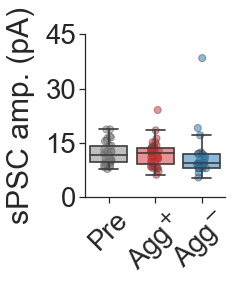

In [107]:
# sPSC_amp
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSC_Amplitude(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSC_Amplitude(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC amp. (pA)', labelpad=10)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,45)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_amp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

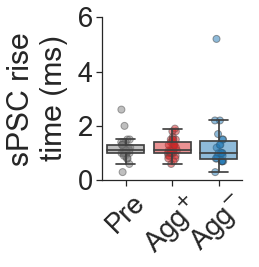

In [29]:
# sPSC rise time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSCs_Rise time', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSCs_Rise time', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC rise\ntime (ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,6)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_rise.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

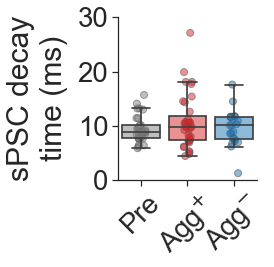

In [30]:
# sPSC decay time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSCs (decay)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSCs (decay)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC decay\ntime (ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_decay.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## Gal+ vs Gal-

In [31]:
gal = ephys[(ephys['Gal_positive'] == 'yes') & (ephys['Behaviour_6hFD'] == 'Agg+')]
no_gal = ephys[(ephys['Gal_positive'] == 'no') & (ephys['Behaviour_6hFD'] == 'Agg+')]
gals = pd.concat([gal,no_gal], axis = 0)
len(no_gal)

4

In [32]:
count_yes_agg = ((ephys['Gal_positive'] == 'yes') & (ephys['Behaviour_6hFD'] == 'Agg+')).sum()
count_no_agg = ((ephys['Gal_positive'] == 'no') & (ephys['Behaviour_6hFD'] == 'Agg+')).sum()
print(f"Number of Gal+ (Agg+) cells: {count_yes_agg}")
print(f"Number of Gal- (Agg+) cells: {count_no_agg}")

Number of Gal+ (Agg+) cells: 10
Number of Gal- (Agg+) cells: 4


Cm(pF) ('yes', 'no') 0.7301587301587302 0.7222222222222223 0.3650793650793651
Gal_positive
no     48.160853
yes    43.144010
Name: Cm(pF), dtype: float64


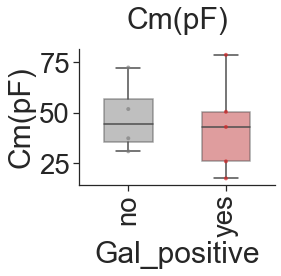

Firing_freq_(Hz)_I0 ('yes', 'no') 0.9342244136152227 0.46711220680761134 0.5977754156927766
Gal_positive
no     2.565
yes    0.730
Name: Firing_freq_(Hz)_I0, dtype: float64


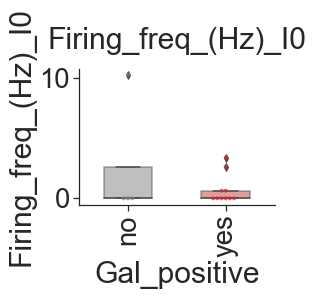

Instant_freq_(Hz) ('yes', 'no') 0.9342244136152227 0.46711220680761134 0.5977754156927766
Gal_positive
no     2.600
yes    0.894
Name: Instant_freq_(Hz), dtype: float64


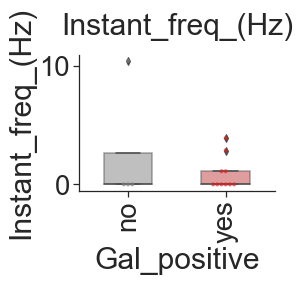

isi_(ms) ('yes', 'no') 0.27650048008343264 0.13825024004171632 0.9651373154082437
Gal_positive
no      97.42
yes    942.50
Name: isi_(ms), dtype: float64


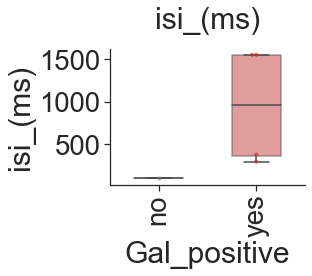

CaT ('yes', 'no') 0.7758674484021668 0.6824333738944282 0.3879337242010834
Gal_positive
no     8.5075
yes    2.4750
Name: CaT, dtype: float64


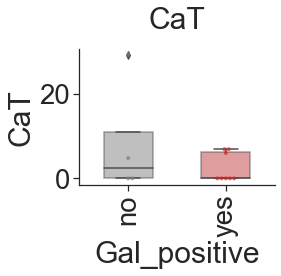

Ih_at_-120mV ('yes', 'no') 0.4744203558661574 0.8090122462959353 0.2372101779330787
Gal_positive
no     3.287500
yes    4.364444
Name: Ih_at_-120mV, dtype: float64


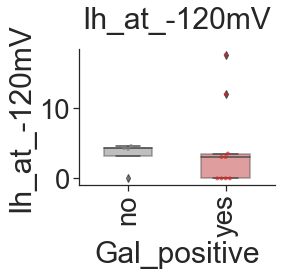

AP_ampl ('yes', 'no') 0.27650048008343264 0.9651373154082437 0.13825024004171632
Gal_positive
no     98.4000
yes    68.9375
Name: AP_ampl, dtype: float64


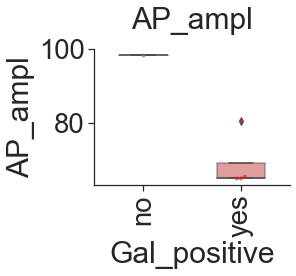

AP_halfwidth ('yes', 'no') 0.27650048008343264 0.13825024004171632 0.9651373154082437
Gal_positive
no     1.71
yes    3.46
Name: AP_halfwidth, dtype: float64


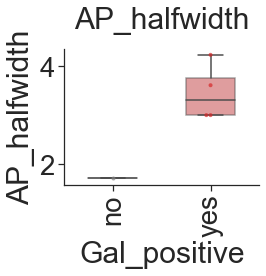

AP_time_to_peak ('yes', 'no') 0.27650048008343264 0.13825024004171632 0.9651373154082437
Gal_positive
no     0.6200
yes    2.1225
Name: AP_time_to_peak, dtype: float64


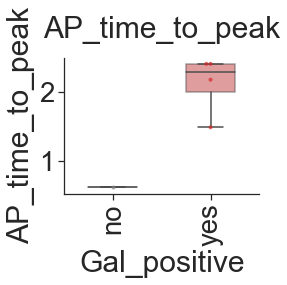

area(mV_ms) ('yes', 'no') 0.27650048008343264 0.13825024004171632 0.9651373154082437
Gal_positive
no     132.0
yes    231.4
Name: area(mV_ms), dtype: float64


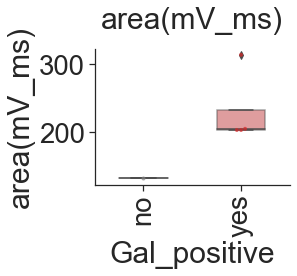

rheobase_at_-60mV_(pA) ('yes', 'no') 1.0 0.56251910040427 0.5
Gal_positive
no     39.500000
yes    21.222222
Name: rheobase_at_-60mV_(pA), dtype: float64


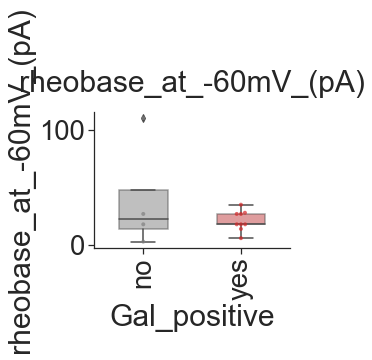

AHP_(mV) ('yes', 'no') 0.27650048008343264 0.13825024004171632 0.9651373154082437
Gal_positive
no    -53.7000
yes   -44.9375
Name: AHP_(mV), dtype: float64


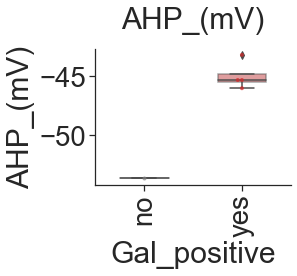

Vm ('yes', 'no') 0.008814274609282705 0.004407137304641352 0.9971165767517787
Gal_positive
no    -54.158175
yes   -39.307557
Name: Vm, dtype: float64


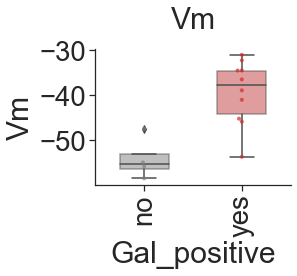

Input_Resistance ('yes', 'no') 0.5886419272719632 0.7565728724281374 0.2943209636359816
Gal_positive
no     672.011750
yes    656.296223
Name: Input_Resistance, dtype: float64


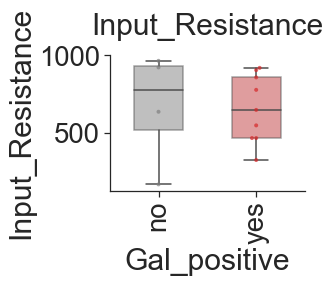

sPSC_frequency ('yes', 'no') 0.4361720023365777 0.21808600116828886 0.8212791006485352
Gal_positive
no     1.634487
yes    2.961646
Name: sPSC_frequency, dtype: float64


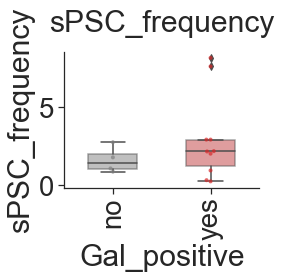

sPSC_Amplitude(pA) ('yes', 'no') 0.3574417987029296 0.8558430341669815 0.1787208993514648
Gal_positive
no     11.9825
yes    10.6930
Name: sPSC_Amplitude(pA), dtype: float64


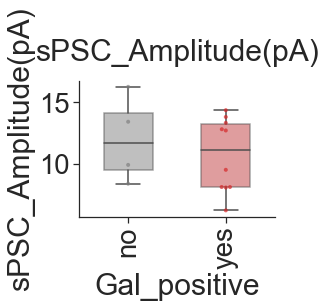

sPSCs_Rise time ('yes', 'no') 0.615526113017221 0.7407589750685232 0.3077630565086105
Gal_positive
no     1.275
yes    1.150
Name: sPSCs_Rise time, dtype: float64


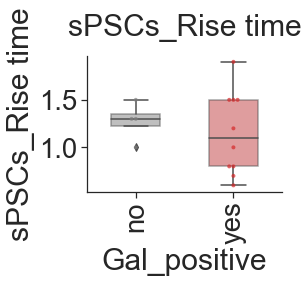

sPSCs (decay) ('yes', 'no') 0.13713139723599588 0.06856569861799794 0.9482519467445016
Gal_positive
no      8.9425
yes    12.8750
Name: sPSCs (decay), dtype: float64


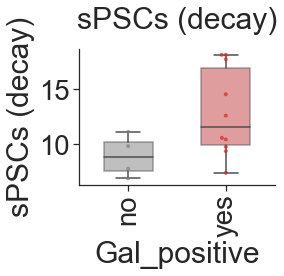

In [33]:
preprocess_plot(ephys[(ephys.Gal_positive.isin(['no', 'yes'])) & (ephys.Behaviour_6hFD.isin(['Agg-', 'Agg+']))], 
                'Gal_positive', 'gal', palette=['Gray', 'Tab:red'], order = ['no', 'yes'], plotting= True)

In [ ]:
gals = pd.concat([gal,no_gal], axis = 0)
gals = gals[gals.Behaviour_6hFD.isin(['Agg+', 'Agg-'])]

ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
   'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for column in ls:
    try:
        _, p = stats.ttest_ind(gals[(gals.Gal_positive == 'yes')][column].dropna(),
                                    gals[(gals.Gal_positive == 'no')][column].dropna(),
                                    equal_var = False)
        print(column , p)


        gals[column] = pd.to_numeric(gals[column])
        fig,ax = plt.subplots(figsize = (2,4))
        sns.swarmplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'])
        sns.boxplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'], boxprops=dict(alpha=0.7))
        sns.despine()
        plt.title(column + '_' + str(p)[:3])
        plt.savefig(f'output_figures/gal_nogal_{column}.png',dpi = 300, bbox_inches = 'tight')
        plt.show()
    except Exception:
        continue

In [ ]:
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre', 'Agg-', 'Agg+'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 
                              'Firing_freq_(Hz)_I0': 'firing_freq', 
                              'sPSC_Amplitude(pA)': 'sPSC_Amplitude'})
model = smf.ols('Input_Resistance ~  ih_current  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

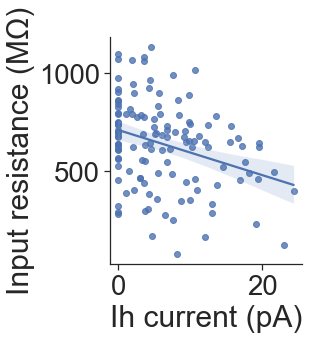

In [ ]:
sns.lmplot(x = 'ih_current', y = 'Input_Resistance', data = trial, palette = ['darkgray', '#F97306', 'blue'])
plt.xlabel('Ih current (pA)')
plt.ylabel('Input resistance (MΩ)')
plt.savefig(f'output_figures/ih_input_resistance.png',dpi = 300, bbox_inches = 'tight')
          


No handles with labels found to put in legend.


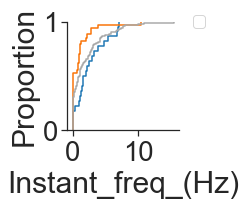

In [ ]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['darkgray', '#F97306', 'Tab:blue']
conds = ['Pre', 'Agg+', 'Agg-']
fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

### Individual plots Gal+ vs Gal-

In [37]:
# gals

In [38]:
print(f"Number of Gal+ neurons: {(gals['Gal_positive'] == 'yes').sum()} from {gals[gals['Gal_positive'] == 'yes']['ID_mouse'].nunique()} mice")
print(f"Number of Gal- neurons: {(gals['Gal_positive'] == 'no').sum()} from {gals[gals['Gal_positive'] == 'no']['ID_mouse'].nunique()} mice")


Number of Gal+ neurons: 10 from 3 mice
Number of Gal- neurons: 4 from 2 mice


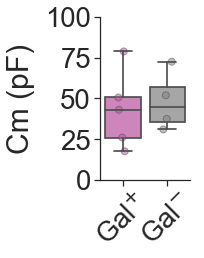

In [39]:
# Cm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Cm(pF)', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Cm(pF)', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0,100)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [40]:
# gals

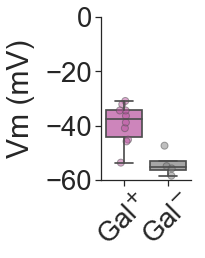

In [41]:
# Vm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Vm', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Vm', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-60, 0)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Vm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

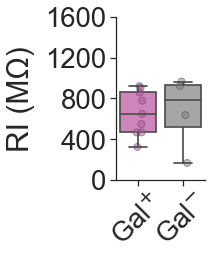

In [42]:
# RI Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Input_Resistance', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Input_Resistance', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 1600)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ri.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

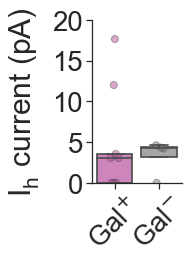

In [43]:
# Ih Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ current (pA)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 20)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ih.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

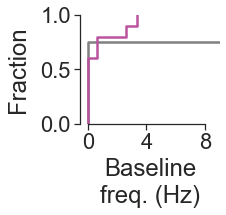

In [44]:
# Firing frequency Gal+ vs Gal-
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=gals, x="Firing_freq_(Hz)_I0", hue="Gal_positive", palette = dual, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/ff.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## silent proportion

## silent proportion
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100',  'npy1r_antag', 'npy2r_antag', 'npykd']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero_reclassified', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

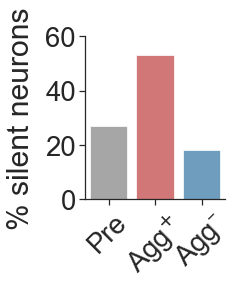

In [46]:
# % silent neurons
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-'], palette = triple, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{–}$'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
sns.despine(bottom=False)
# g.tick_params(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

In [47]:
silent_df = silent_prop.loc[:, ['Behaviour_6hFD', 'silent']]

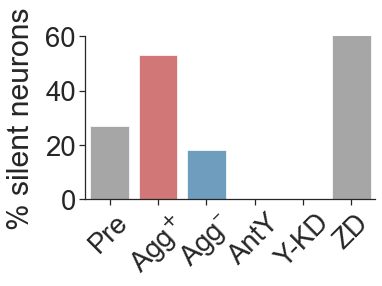

In [ ]:
silent_df

I_zero        phasic  silent  tonic  All
Gal_positive                            
no                 0       3      1    4
yes                2       6      2   10
All                2       9      3   14
0.6270890852730562


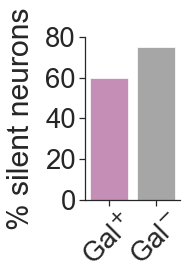

In [ ]:
plt.subplots(figsize = (8,4))
sns.barplot(x = 'Behaviour_6hFD', y = 'silent', data = silent_df, palette = ['gray', 'Tab:red', 'Tab:blue', 'gray', 'gray', 'Tab:red', 'Tab:red', 'Tab:red'], alpha = 0.7)
plt.xticks(fontsize = 30, rotation = 90)
ax = plt.gca()
plt.ylabel('% Silent', fontsize = 35)
plt.yticks(fontsize = 30)
plt.xlabel('')



ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('output_figures/silent_prop.pdf',dpi = 300, bbox_inches = 'tight')

I_zero        phasic  silent  tonic  All
Gal_positive                            
no                 0       3      1    4
yes                2       6      2   10
All                2       9      3   14
0.6270890852730562


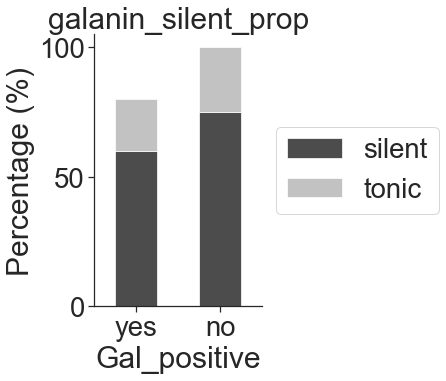

In [ ]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

In [51]:
silent_prop

I_zero,Gal_positive,silent,tonic
1,yes,60.0,20.0
0,no,75.0,25.0


## adaptive prop

Adaptive        ?  no  yes  All
Behaviour_6hFD                 
Pre             1  15   23   39
Agg+            1  12   20   33
Agg-            0  18    3   21
All             2  45   46   93
0.004258784881561054


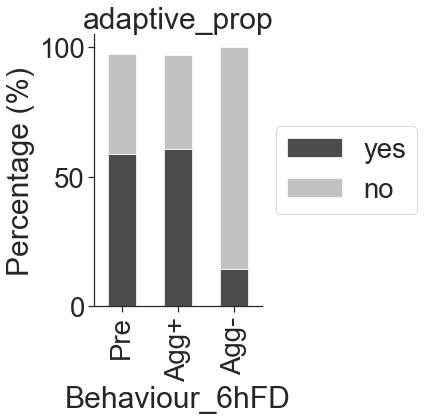

In [ ]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-', 'npykd']
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])

prop_plot(ad_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('adaptive_prop')
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

In [ ]:
ad_prop

Adaptive,Behaviour_6hFD,yes,no
0,Pre,58.974359,38.461538
1,Agg+,60.606061,36.363636
2,Agg-,14.285714,85.714286


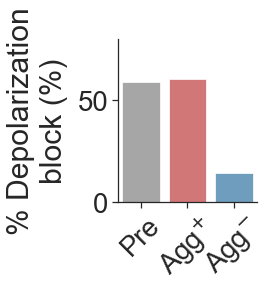

In [54]:
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(x = 'Behaviour_6hFD', y = 'yes', data = ad_prop, order=['Pre', 'Agg+', 'Agg-'], palette= triple, alpha = 0.7)

g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% Depolarization\nblock (%)', labelpad=10)
g.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

plt.xlabel('')
plt.ylim(top=80)
plt.yticks(np.arange(0, 81, 50))
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/adaptive_prop.pdf',
dpi=300,bbox_inches='tight', transparent=True)

Adaptive      no  yes  All
Gal_positive              
no             2    2    4
yes            3    6    9
All            5    8   13
1.0


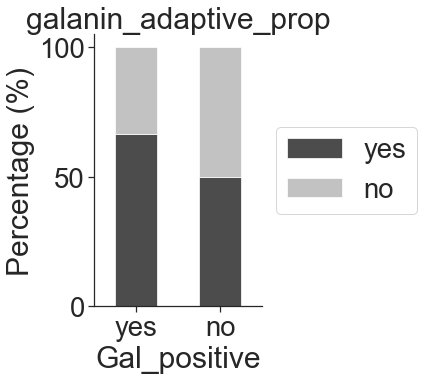

In [ ]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

## calcium T prop

cat_categ        no  no   yes  yes   All
Behaviour_6hFD                          
Pre              46    0   31     0   77
Agg+             21    0   11     0   32
Agg-              9    1   11     1   22
npy_10           12    2    1     0   15
npy1r_antag       9    0    6     0   15
npy2r_antag       8    0    2     0   10
ZD7288            6    0    3     0    9
All             111    3   65     1  180
0.022283798305559252


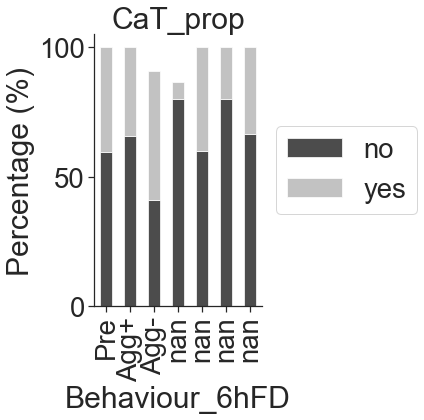

In [ ]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

cat_categ     no  yes  All
Gal_positive              
no             2    2    4
yes            5    4    9
All            7    6   13
1.0


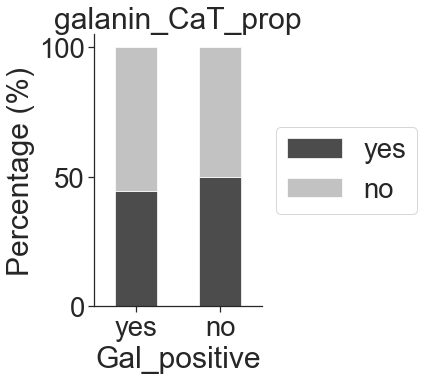

In [ ]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

## IH prop

IH              no  yes  All
Behaviour_6hFD              
Pre             23   54   77
Agg+            12   20   32
Agg-             1   21   22
npy_10           7    8   15
npy1r_antag      4   11   15
npy2r_antag      2    8   10
ZD7288           9    0    9
All             58  122  180
4.7243451218157166e-05


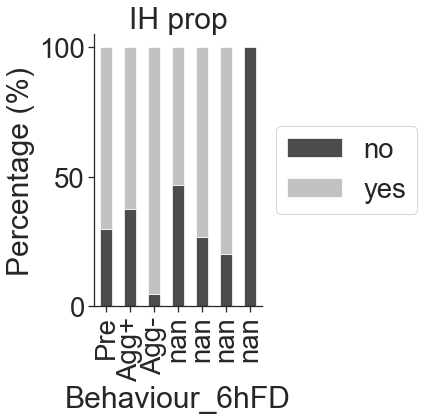

In [ ]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic                6   34   40
silent               36   44   80
stonic                0    1    1
tonic                32   69  101
All                  74  148  222
0.008995471625070976


Text(0.5, 0, '')

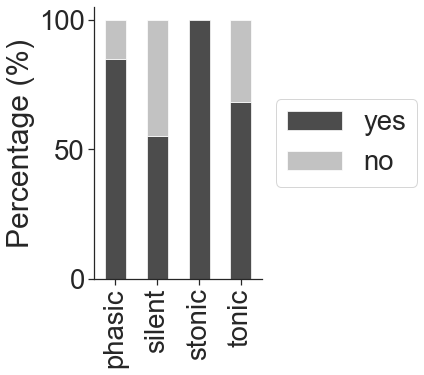

In [ ]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# Ramp analysis

In [ ]:
from glob import glob
path = '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp'
states = ['Pre', 'Agg+', 'Agg-']
# list all directory in filepath
df_state = pd.DataFrame()

for state in states:
    files = [file for file in glob(f'{path}/{state}/*.xlsx')]
    df_files = []
    for file in files:
        try:
            df_file = pd.read_excel(file)
            df_file['filename'] = file
        except ValueError:
            print(file, state)
        df_files.append(df_file)

    df = pd.concat(df_files)
    df['state'] = state
    df_state = pd.concat([df_state, df])
    
        

In [ ]:
df_state

In [ ]:
df_state.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
# df_state['Injected'] = pd.Categorical(df_state['Injected'], df_state['Injected'].unique()[:-2]).as_ordered()
df_state.sort_values('Injected', inplace = True)

df_state['state'] = pd.Categorical(df_state['state'], states).as_ordered()
# df_state.sort_values('Injected', inplace = True)


num_spike = df_state.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')

df_all = df_state.groupby(['filename', 'Injected'], dropna = False).first().reset_index().drop_duplicates()

# df_state.loc[df['Event start '] == 0,'Event start '] = 2080
df_all['latency'] = df_all['Event start ']- df_all['Ramp_start']
df_all = df_all[df_all['latency'] > 0]
df_all['num_spike'] = num_spike.num_spike



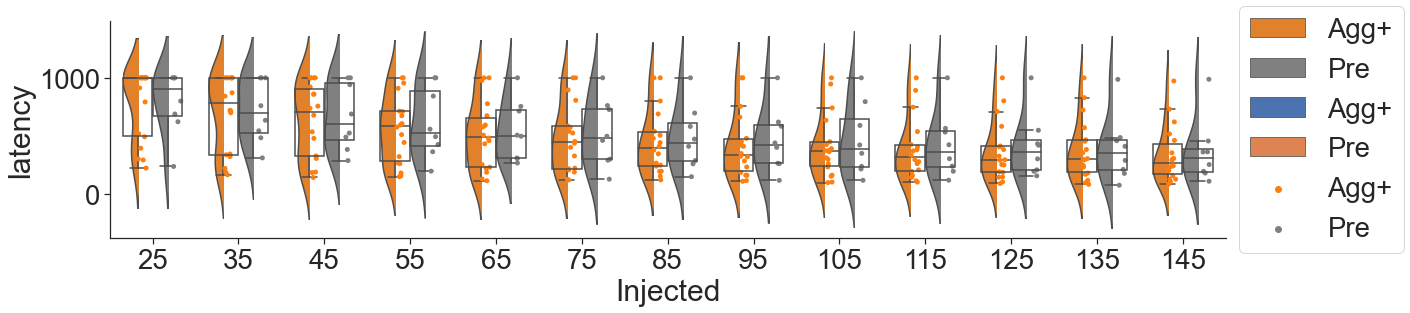

In [61]:
prop = 'num_spike'

fig, ax = plt.subplots(figsize = [20,4])

palette = ['gray', 'Tab:red', 'Tab:blue']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.swarmplot(x  = 'Injected', y = prop, hue = 'state',
               dodge = True, data = df_all, palette=palette, ax=ax)

sns.boxplot(x  = 'Injected', y = prop, hue = 'state',
                data = df_all, saturation=1, showfliers=False,
            width=0.7, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)

# turn off legend
leg = ax.get_legend()
if leg:
    leg.remove()

    sns.despine()



In [62]:
model = smf.ols('latency ~ C(Injected) * C(state)', data=df_all).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

# Estrous cycle influence

I_zero             phasic  silent  tonic  All
estrous_stage                                
?                       1       1      2    4
D                       5       7     15   27
E                       2       3      2    7
M                       2       6     14   22
P                       6       6     11   23
VS to be stained        0       0      1    1
no VS                   1       2      9   12
not taken               1       2      1    4
All                    18      27     55  100
0.8443773071908964


ValueError: No objects to concatenate

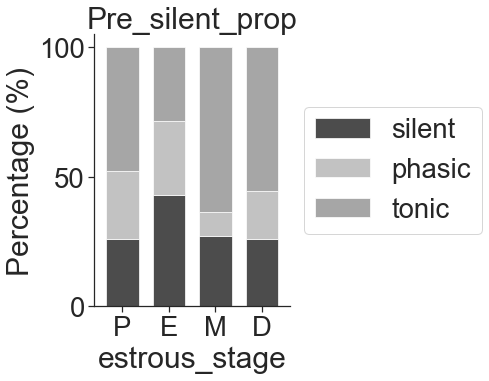

In [ ]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', 
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['black', 'darkgray','gray'],
            figsize = (3.5,5), alpha = 0.7, width = 0.7)
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

I_zero             phasic  silent  tonic  All
estrous_stage                                
?                       1       1      2    4
D                       5       7     15   27
E                       2       3      2    7
M                       2       6     14   22
P                       6       6     11   23
VS to be stained        0       0      1    1
no VS                   1       2      9   12
not taken               1       2      1    4
All                    18      27     55  100
0.8443773071908964


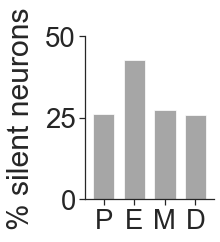

In [ ]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg-','Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre']: #Post Pre
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', y = 'silent',
            kind = 'bar', 
            stacked = False,  
            mark_right = False,
            color = ['gray'],
            figsize = (2.3,3), alpha = 0.7, width = 0.7)
 
        
    
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('% silent neurons', labelpad=10)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.xlabel(None)
    plt.ylim(0,50) 
    ax.get_legend().remove()
#     ax.yaxis.set_major_locator(plt.MaxNLocator(4))

#     plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_estrous_pre.pdf',
#                 dpi=300,bbox_inches='tight', transparent=True)

-0.7534196735891932 0.24658032641080685


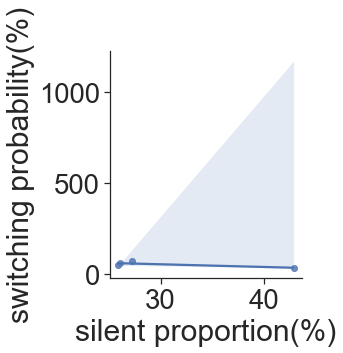

In [66]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

In [ ]:
state_df.estrous_stage.unique()

array(['P', 'M', 'D', 'no VS', 'E', 'not taken', '?', 'VS to be stained '],
      dtype=object)

Ih_at_-120mV 0.020809059495937948


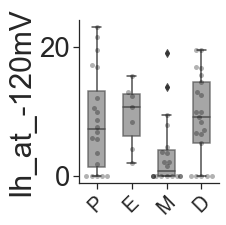

In [68]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

# ls = ['Ih_at_-120mV']

for state in ['Pre']:
    for column in ls:
        # state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df = ephys.copy()
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        state_df = state_df[state_df.Behaviour_6hFD == state]
        
        try:

            _, p = stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna())
            

            
            if p < 0.05:
                print(column , p)

                fig,ax = plt.subplots(figsize = (2.5,3))
                sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 0.3, color = 'black')
                sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5, palette = ['gray'])
                sns.despine()
                plt.xticks(rotation = 45, fontsize = 20)
                # plt.ylabel('Ih current (pA)', fontsize = 25)
                plt.xlabel('')
            
                # plt.title(f'{state}_{column}', pad = 20)
                plt.savefig(f'output_figures/{state}_{column}.png',dpi = 300, bbox_inches = 'tight')
            
            plt.show()
        except Exception:
            continue

In [ ]:
state_df

,Unnamed: 0,experiment_day,sex,Gal_positive,state,estrous_stage,ID_mouse,Genotype,Behaviour_6hFD,Cm(pF),...,Vm,Input_Resistance,sPSC_frequency,sPSC_Amplitude(pA),sPSCs_Rise time,sPSCs (decay),AC-I0,AC_-60,Comments,estrous_confirmation
0,0,S1C1 20012023,F,no,Virgin-Gal -,P,JKAM54.2d,Gal-cre KI87; Rosa26 Tomato (Ai9),Pre,65.734306,...,-49.128138,250.106759,0.683099,7.7800,1.0,6.4965,NaN,NaN,NaN,NaN
1,1,S1C2 20012023,F,no,Virgin-Gal -,P,JKAM54.2d,Gal-cre KI87; Rosa26 Tomato (Ai9),Pre,75.822056,...,-50.497848,122.285453,0.826316,16.7550,1.1,8.8464,NaN,NaN,NaN,NaN
2,2,S1C3 20012023,F,no,Virgin-Gal -,P,JKAM54.2d,Gal-cre KI87; Rosa26 Tomato (Ai9),Pre,50.911152,...,-53.084624,672.766784,3.153537,9.6000,1.1,8.3191,NaN,NaN,NaN,NaN
3,3,S2C4 20012023,F,no,Virgin-Gal -,P,JKAM54.2d,Gal-cre KI87; Rosa26 Tomato (Ai9),Pre,21.407586,...,-42.987736,744.864094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,S2C5 20012023,F,no,Virgin-Gal -,P,JKAM54.2d,Gal-cre KI87; Rosa26 Tomato (Ai9),Pre,40.243429,...,-55.055603,627.416182,4.314286,8.3206,1.0,9.4346,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,97,S2C1 22072023,F,Unknown,pan-MPOA-virgin,P,BRAC8524.1g,WT,Pre,NaN,...,-44.099370,898.360322,4.356115,8.9000,1.0,8.4000,NaN,NaN,NaN,confirmed
98,98,S1C1 23072023,F,Unknown,pan-MPOA-virgin,E,BRAC8524.1h,WT,Pre,NaN,...,-54.947228,304.960251,3.169435,13.2000,1.4,10.1000,NaN,NaN,NaN,confirmed
99,99,S1C2 23072023,F,Unknown,pan-MPOA-virgin,E,BRAC8524.1h,WT,Pre,NaN,...,-48.105279,858.972471,0.875000,8.5000,1.3,NaN,NaN,NaN,NaN,confirmed
100,100,S2C1 23072023,F,Unknown,pan-MPOA-virgin,E,BRAC8524.1h,WT,Pre,NaN,...,-39.436007,649.572275,1.509804,10.6000,0.9,7.9000,NaN,NaN,NaN,confirmed


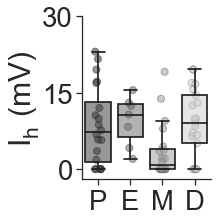

In [70]:
# Ih - estrous Pre
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = state_df, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = state_df, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [113]:
group_counts = state_df['estrous_stage'].value_counts()
print(f"Cell numbers: \n{group_counts}")
unique_counts = state_df.groupby('estrous_stage')['ID_mouse'].nunique()
print(f"Mouse numbers: \n{unique_counts}")

Cell numbers: 
D    27
P    23
M    22
E     7
Name: estrous_stage, dtype: int64
Mouse numbers: 
estrous_stage
P    7
E    2
M    4
D    2
Name: ID_mouse, dtype: int64


cat_categ          no  yes  All
estrous_stage                  
?                   1    3    4
D                  10   11   21
E                   3    4    7
M                  15    5   20
P                  14    6   20
VS to be stained    1    0    1
not taken           2    2    4
All                46   31   77
0.2559860927442175
cat_categ estrous_stage         no        yes
4                     P  70.000000  30.000000
2                     E  42.857143  57.142857
3                     M  75.000000  25.000000
1                     D  47.619048  52.380952


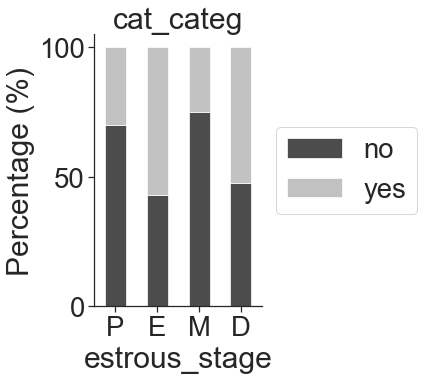

0.9437940453341873 0.056205954665812685


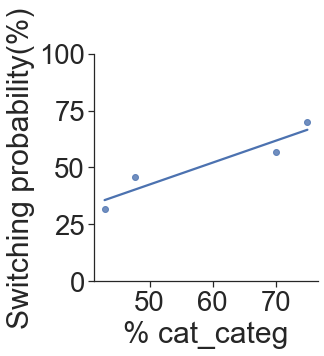

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   16   21
E                   0    7    7
M                  10   10   20
P                   5   15   20
VS to be stained    1    0    1
not taken           2    2    4
All                23   54   77
0.056205483511176685
IH estrous_stage         no         yes
4              P  25.000000   75.000000
2              E   0.000000  100.000000
3              M  50.000000   50.000000
1              D  23.809524   76.190476


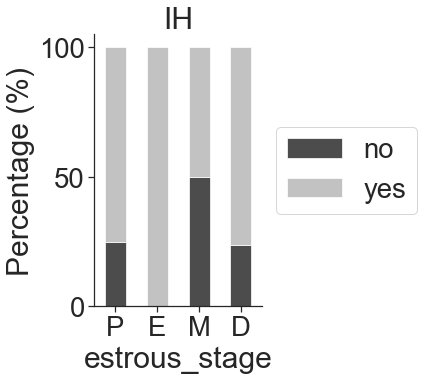

0.9687218215661224 0.03127817843387759


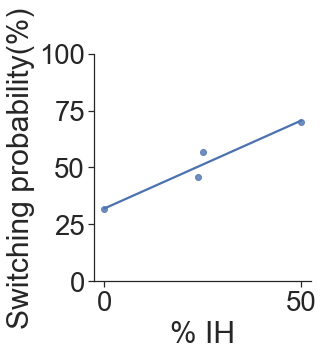

Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    5    9
E                  0   1    0    1
M                  0   7   10   17
P                  1   3    6   10
VS to be stained   0   0    1    1
All                1  15   23   39
0.803662355695632
Adaptive estrous_stage          no        yes
4                    P   30.000000  60.000000
2                    E  100.000000   0.000000
3                    M   41.176471  58.823529
1                    D   44.444444  55.555556


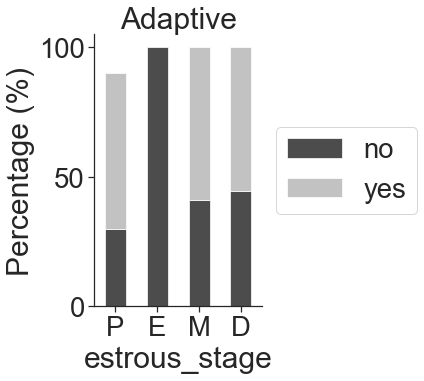

-0.7996129957560257 0.20038700424397426


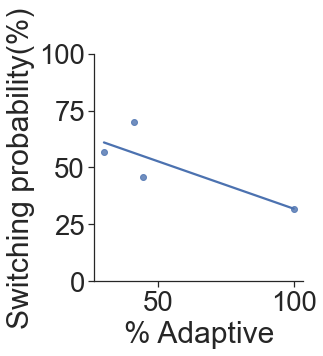

In [71]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys_pre = ephys[ephys.Behaviour_6hFD == 'Pre']

for column in ['cat_categ', 'IH', 'Adaptive']:
    esprop = proportion(ephys_pre, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)

    sns.lmplot(x = 'no', y = 'switching probability', data = corr, ci = None)
    plt.ylim([0, 100])
    plt.xlabel(f'% {column}')
    plt.ylabel('Switching probability(%)')
    plt.savefig(f'output_figures/{column}_switching_corr.png', dpi = 300, bbox_inches = 'tight')
    plt.show()

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   16   21
E                   0    7    7
M                  10   10   20
P                   5   15   20
VS to be stained    1    0    1
not taken           2    2    4
All                23   54   77
0.056205483511176685
Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    5    9
E                  0   1    0    1
M                  0   7   10   17
P                  1   3    6   10
VS to be stained   0   0    1    1
All                1  15   23   39
0.803662355695632
-0.4469053317142254 0.5530946682857746


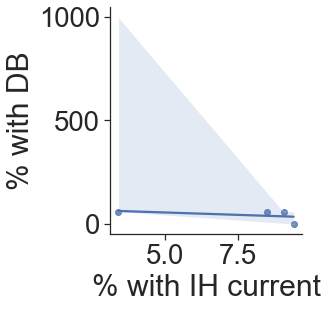

In [ ]:

cols = ['no', 'yes']
estrous_stages = ['P', 'E', 'M', 'D']
ih_prop = proportion(ephys_pre, 'estrous_stage', 'IH', cols)
ih_est_mean = ephys_pre.groupby('estrous_stage')['Ih_at_-120mV'].mean().reset_index()
adaptive_prop = proportion(ephys_pre, 'estrous_stage', 'Adaptive', cols)
merged_df = pd.merge(ih_est_mean, adaptive_prop, on = 'estrous_stage')
merged_df = merged_df[merged_df.estrous_stage.isin(estrous_stages)]


r, p = sp.stats.pearsonr(merged_df['Ih_at_-120mV'], merged_df['yes'])
print(r, p)

sns.lmplot(x = 'Ih_at_-120mV', y = 'yes', data = merged_df)
# plt.ylim([0, /100])
plt.xlabel('% with IH current')
plt.ylabel('% with DB')
plt.show()

## Individual plots

### Pre

In [73]:
# We're plotting by estrous state from all 'Pre' values here
ephys_estrous = ephys[ephys['Behaviour_6hFD'] == 'Pre']

In [74]:
print(f"Number of P neurons: {(ephys_estrous['estrous_stage'] == 'P').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_estrous['estrous_stage'] == 'E').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_estrous['estrous_stage'] == 'M').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_estrous['estrous_stage'] == 'D').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

Number of P neurons: 23 from 7 mice
Number of E neurons: 7 from 2 mice
Number of M neurons: 22 from 4 mice
Number of D neurons: 27 from 2 mice


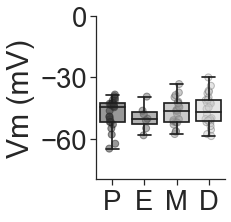

In [75]:
# Membrane voltage - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

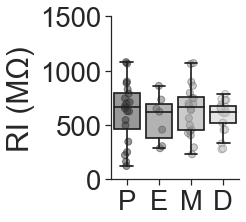

In [76]:
# Input resistance - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

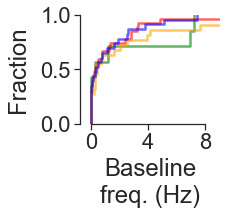

In [77]:
# Firing frequency - estrous Pre

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first.
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_estrous2 = ephys_estrous[ephys_estrous['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_estrous2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/ff_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

### Post (Agg+/- pooled)

In [78]:
# We're plotting by estrous state from all 'Agg+' and 'Agg-' values here
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_post = ephys[(ephys['Behaviour_6hFD'] == 'Agg+') | (ephys['Behaviour_6hFD'] == 'Agg-')]

In [79]:
print(f"Number of P neurons: {(ephys_post['estrous_stage'] == 'P').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_post['estrous_stage'] == 'E').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_post['estrous_stage'] == 'M').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_post['estrous_stage'] == 'D').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

Number of P neurons: 12 from 2 mice
Number of E neurons: 4 from 1 mice
Number of M neurons: 24 from 4 mice
Number of D neurons: 8 from 2 mice


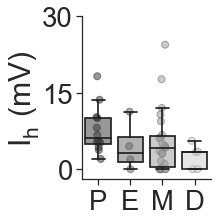

In [80]:
# Ih - Post
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ih_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

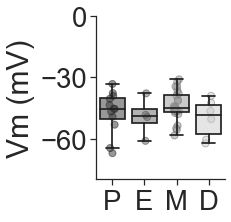

In [81]:
# Membrane voltage - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

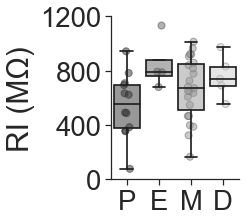

In [82]:
# Input resistance - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1200)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

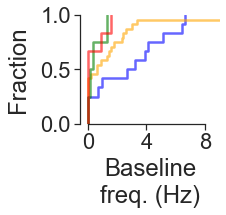

In [83]:
# Firing frequency - estrous Post

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first. NOTE THAT THIS REMOVES E.G. 'P to E' ETC. 
#- IT MIGHT BE BETTER TO RECLASSIFY THOSE
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_post2 = ephys_post[ephys_post['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_post2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/ff_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

# NPY administration

In [86]:
# reload data and convert all instances of NPY application to 'npy'
# UPDATE: use updated npy_100 column!
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_npy = ephys.copy()
# ephys_npy['Behaviour_6hFD'] = ephys_npy['Behaviour_6hFD'].replace(['npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100'], 'npy')


In [87]:
print(f"Number of Pre neurons: {(ephys_npy['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of NPY neurons: {(ephys_npy['Behaviour_6hFD'] == 'npy_100').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'npy_100']['ID_mouse'].nunique()} mice")

Number of Pre neurons: 102 from 12 mice
Number of NPY neurons: 7 from 3 mice


In [88]:
# ephys_npy

In [89]:
ephys_npy.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100',
       'agrp_100_paired', 'agrp_100', 'ZD7288', 'ZD7288_20'], dtype=object)

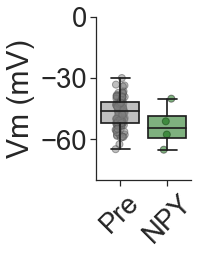

In [90]:
# Membrane voltage / RMP + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

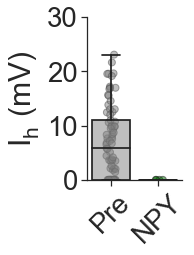

In [91]:
# Ih + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

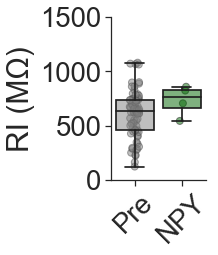

In [92]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [93]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'npy_100']
silent_npy = proportion(ephys_npy[ephys_npy.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_npy['Behaviour_6hFD'] = pd.Categorical(silent_npy['Behaviour_6hFD'], cat)
silent_npy = silent_npy.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Pre                 18      27     55  100
npy_100              0       4      0    4
All                 18      31     55  104
0.00746100976916917


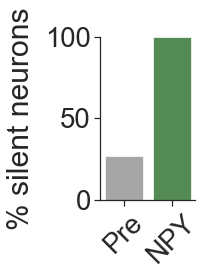

In [94]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_npy, x="Behaviour_6hFD", y="silent", order=['Pre', 'npy_100'], palette = npy, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Pre', 'NPY'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
# ax.yaxis.set_major_locator(plt.MaxNLocator(5))
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [95]:
# subset df for those groups needed for firing freq. plot
ephys_npy_ff = ephys_npy.loc[(ephys_npy['Behaviour_6hFD'] == 'Pre') | (ephys_npy['Behaviour_6hFD'] == 'npy_100')]

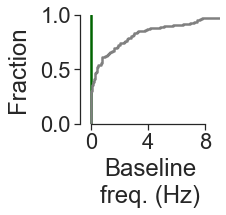

In [96]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_npy_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = npy, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

# AgRP administration

In [97]:
# reload data and convert all instances of AgRP application to 'agrp'
# UPDATE: use the updated agrp_100 column!
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_agrp = ephys.copy()
# ephys_agrp['Behaviour_6hFD'] = ephys_agrp['Behaviour_6hFD'].replace(['agrp_100_paired', 'agrp_100'], 'agrp')

In [98]:
# ephys_agrp.Behaviour_6hFD.unique()

In [99]:
print(f"Number of Pre neurons: {(ephys_agrp['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of AgRP neurons: {(ephys_agrp['Behaviour_6hFD'] == 'agrp_100').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp_100']['ID_mouse'].nunique()} mice")

Number of Pre neurons: 102 from 12 mice
Number of AgRP neurons: 7 from 1 mice


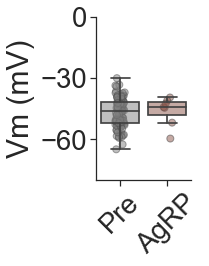

In [100]:
# Membrane voltage / RMP + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order=['Pre', 'agrp_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order = ['Pre', 'agrp_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

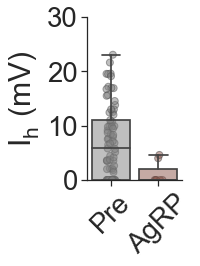

In [101]:
# Ih + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order=['Pre', 'agrp_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order = ['Pre', 'agrp_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

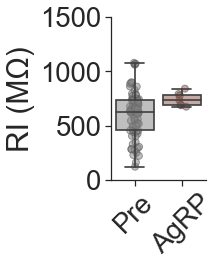

In [102]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order=['Pre', 'agrp_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order = ['Pre', 'agrp_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [103]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'agrp_100']
silent_agrp = proportion(ephys_agrp[ephys_agrp.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_agrp['Behaviour_6hFD'] = pd.Categorical(silent_agrp['Behaviour_6hFD'], cat)
silent_agrp = silent_agrp.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Pre                 18      27     55  100
agrp_100             2       1      4    7
All                 20      28     59  107
0.6700776176645687


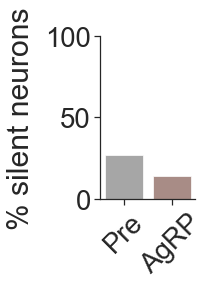

In [104]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_agrp, x="Behaviour_6hFD", y="silent", order=['Pre', 'agrp_100'], palette = agrp, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Pre', 'AgRP'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [105]:
# subset df for those groups needed for firing freq. plot
ephys_agrp_ff = ephys_agrp.loc[(ephys_agrp['Behaviour_6hFD'] == 'Pre') | (ephys_agrp['Behaviour_6hFD'] == 'agrp_100')]

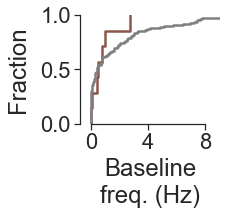

In [106]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_agrp_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = agrp, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)